In [5]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Traffic State Optimization" --recursive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/Traffic State Optimization':
evaluate-and-compare.ipynb
finetune.ipynb
MTID
mtid_dataset_extraction_and_inspection.ipynb
mtid.zip
pipeline_results.pdf
runs
Test
traffic_dataset
traffic_dataset.yaml
Vehicle_detection_density_ratio.ipynb
vietnam.coco

'/content/drive/MyDrive/Traffic State Optimization/MTID':
Drone  drone-mscoco.json  Infrastructure  infrastructure-mscoco.json

'/content/drive/MyDrive/Traffic State Optimization/MTID/Drone':
0  1000  2000  3000  3100  3200  3300  frames

'/content/drive/MyDrive/Traffic State Optimization/MTID/Drone/0':
 annotations.csv	  seq3-drone_0000311.jpg   seq3-drone_0000625.jpg
'A V├ªr op p├Ñ.txt'	  seq3-drone_0000312.jpg   seq3-drone_0000626.jpg
 DIR.py			  seq3-drone_0000313.jpg   seq3-drone_0000627.jpg
 rgbMasks		  seq3-drone_0000314.jpg   seq3-drone_0000628.jpg
 seq3-drone_0000001.jpg   seq3-dr

In [ ]:
!pip install ultralytics

from google.colab import drive
drive.mount('/content/drive')
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ultralytics import YOLO
from collections import defaultdict

# ---------------------------------------------------------------------------
# Ground truth – your manual counts
# format: image_number : [moto+bicycle, car, bus+truck]
# weights: moto/bicycle = 1, car = 2, bus = 4, truck = 5
# ---------------------------------------------------------------------------

GROUND_TRUTH = {
     1 : [42,  2,  3],
     2 : [42, 13,  0],
     3 : [ 7,  0,  0],
     4 : [ 8,  0,  1],
     5 : [10,  2,  0],
     6 : [14,  4,  0],
     7 : [55, 26,  8],
     8 : [61,  8,  4],
     9 : [39, 21,  1],
    10 : [42, 27,  3],
    11 : [14, 36,  4],
    12 : [21, 10,  0],
    13 : [74, 23,  2],
    14 : [13,  6,  1],
    15 : [32, 19,  1],
    16 : [32, 30,  0],
    17 : [16, 33,  6],
    18 : [53,  6,  0],
    19 : [27,  3,  0],
    20 : [42,  5,  0],
    21 : [36,  1,  0],
    22 : [25,  7,  0],
}

SMALL_CLASSES  = {"bicycle", "motorcycle"}
CAR_CLASSES    = {"car"}
LARGE_CLASSES  = {"bus", "truck"}

def extract_counts(results) -> list[int] :
    """Extract [small, car, large] counts from YOLO results for one image."""
    counts = defaultdict(int)
    for box in results.boxes :
        label = results.names[int(box.cls[0])]
        counts[label] += 1
    small = sum(counts[c] for c in SMALL_CLASSES)
    car   = sum(counts[c] for c in CAR_CLASSES)
    large = sum(counts[c] for c in LARGE_CLASSES)
    return [small, car, large]

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------

TEST_DIR      = "/content/drive/MyDrive/Traffic State Optimization/Test"
BASELINE_PT   = "yolov8m.pt"
FINETUNED_PT  = "/content/drive/MyDrive/Traffic State Optimization/runs/traffic_training/weights/best.pt"
OUT_BASELINE  = "/content/runs/detect/baseline"
OUT_FINETUNED = "/content/runs/detect/finetuned"

# ---------------------------------------------------------------------------
# Run inference
# ---------------------------------------------------------------------------

baseline_model  = YOLO(BASELINE_PT)
finetuned_model = YOLO(FINETUNED_PT)

baseline_results  = baseline_model.predict(
    source  = TEST_DIR,
    conf    = 0.25,
    save    = True,
    project = "/content/runs/detect",
    name    = "baseline",
)

finetuned_results = finetuned_model.predict(
    source  = TEST_DIR,
    conf    = 0.25,
    save    = True,
    project = "/content/runs/detect",
    name    = "finetuned",
)

# Map image number → prediction counts
# Results are sorted by filename so index matches image number
baseline_counts  = {}
finetuned_counts = {}

image_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".jpg")
])

for i, (r_base, r_fine, fname) in enumerate(
        zip(baseline_results, finetuned_results, image_files), start=1) :
    baseline_counts[i]  = extract_counts(r_base)
    finetuned_counts[i] = extract_counts(r_fine)

print("Inference done.")
print(f"Baseline  : {len(baseline_counts)} images")
print(f"Finetuned : {len(finetuned_counts)} images")

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/22 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_01.jpg: 384x640 26 persons, 2 cars, 24 motorcycles, 1 bus, 86.5ms
image 2/22 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_02.jpg: 384x640 15 persons, 13 cars, 14 motorcycles, 1 truck, 2 backpacks, 1 handbag, 25.1ms
image 3/22 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_03.jpg: 416x640 15 persons, 7 motorcycles, 1 stop sign, 47.9ms
image 4/22 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_04.jpg: 448x640 12 persons, 3 cars, 12 motorcycles, 1 bus, 6 traffic lights, 1 backpack, 46.4ms
image 5/22 /content/drive/MyDrive/Traffic State 

In [ ]:
# ---------------------------------------------------------------------------
# compare_predictions
#
# images_to_show : list of image numbers e.g. [1, 3, 7, 13]
#                  or None to show all
# num_images     : if images_to_show is None, show first N
# ---------------------------------------------------------------------------

import pandas as pd

def compare_predictions(images_to_show   = None,
                         num_images       = 5,
                         show_table       = True,
                         show_grid        = True,
                         img_height_inches = 3.5) :

    all_nums = sorted(GROUND_TRUTH.keys())
    nums     = [n for n in images_to_show if n in GROUND_TRUTH] \
               if images_to_show is not None else all_nums[:num_images]

    # ── PANDAS TABLE ────────────────────────────────────────────────────
    if show_table :

        groups = {
            "moto + bicycle" : 0,
            "car"            : 1,
            "bus + truck"    : 2,
        }

        rows = []
        for n in nums :
            gt   = GROUND_TRUTH[n]
            base = baseline_counts.get(n,  [0, 0, 0])
            fine = finetuned_counts.get(n, [0, 0, 0])
            row  = {"image" : f"traffic_{n:02d}"}

            WEIGHTS       = [1, 2, 4.5]
            gt_weighted   = sum(gt[c]   * WEIGHTS[c] for c in range(3))
            base_weighted = sum(base[c] * WEIGHTS[c] for c in range(3))
            fine_weighted = sum(fine[c] * WEIGHTS[c] for c in range(3))

            for group, c in groups.items() :
                row[f"{group} | ground truth"] = gt[c]
                row[f"{group} | baseline"]     = base[c]
                row[f"{group} | finetuned"]    = fine[c]
                row[f"{group} | Δ baseline"]   = base[c] - gt[c]
                row[f"{group} | Δ finetuned"]  = fine[c] - gt[c]

            row["accuracy | baseline"]  = round(min(base_weighted, gt_weighted) / gt_weighted * 100, 1) if gt_weighted > 0 else 0.0
            row["accuracy | finetuned"] = round(min(fine_weighted, gt_weighted) / gt_weighted * 100, 1) if gt_weighted > 0 else 0.0
            rows.append(row)

        # totals row
        totals  = {"image" : "TOTAL"}
        WEIGHTS = [1, 2, 4.5]

        gt_wt   = sum(sum(GROUND_TRUTH[n][c]                * WEIGHTS[c] for c in range(3)) for n in nums)
        base_wt = sum(sum(baseline_counts.get(n,[0,0,0])[c]  * WEIGHTS[c] for c in range(3)) for n in nums)
        fine_wt = sum(sum(finetuned_counts.get(n,[0,0,0])[c] * WEIGHTS[c] for c in range(3)) for n in nums)

        for group, c in groups.items() :
            gt_t   = sum(GROUND_TRUTH[n][c]                for n in nums)
            base_t = sum(baseline_counts.get(n,[0,0,0])[c]  for n in nums)
            fine_t = sum(finetuned_counts.get(n,[0,0,0])[c] for n in nums)
            totals[f"{group} | ground truth"] = gt_t
            totals[f"{group} | baseline"]     = base_t
            totals[f"{group} | finetuned"]    = fine_t
            totals[f"{group} | Δ baseline"]   = base_t - gt_t
            totals[f"{group} | Δ finetuned"]  = fine_t - gt_t

        totals["accuracy | baseline"]  = round(min(base_wt, gt_wt) / gt_wt * 100, 1) if gt_wt > 0 else 0.0
        totals["accuracy | finetuned"] = round(min(fine_wt, gt_wt) / gt_wt * 100, 1) if gt_wt > 0 else 0.0
        rows.append(totals)

        df = pd.DataFrame(rows).set_index("image")

        # multi-level column header
        df.columns = pd.MultiIndex.from_tuples(
            [tuple(c.split(" | ")) for c in df.columns]
        )

        # color Δ columns: red = undercount, green = overcount, grey = exact
        def color_delta(val) :
            if not isinstance(val, (int, float)) :
                return ""
            if val < 0   : return "color: #E05353"
            if val > 0   : return "color: #4A9E6B"
            return "color: grey"

        delta_cols = [c for c in df.columns if "Δ" in c[1]]
        acc_cols = [c for c in df.columns if "accuracy" in c[0]]

        def color_accuracy(val) :
            if not isinstance(val, (int, float)) :
                return ""
            if val >= 80 : return "color: #1A7A5E; font-weight: bold"
            if val >= 60 : return "color: #B8860B"
            return "color: #E05353"

        styled = (df.style
                    .map(color_delta,    subset = delta_cols)
                    .map(color_accuracy, subset = acc_cols)
                    .format("{:.1f}%", subset = acc_cols)
                    .set_table_styles([
                        {"selector" : "th", "props" : [("text-align", "center"), ("font-size", "12px")]},
                        {"selector" : "td", "props" : [("text-align", "center"), ("font-size", "12px")]},
                        {"selector" : "tr:last-child", "props" : [("font-weight", "bold"), ("border-top", "2px solid #999")]},
                    ]))
        display(styled)

    # ── VISUAL GRID ──────────────────────────────────────────────────────
    if not show_grid :
        return

    n_rows = len(nums)
    fig, axes = plt.subplots(n_rows, 3,
                              figsize = (img_height_inches * 3 * 1.6,
                                         img_height_inches * n_rows))
    if n_rows == 1 :
        axes = [axes]

    for row_idx, n in enumerate(nums) :
        fname = f"traffic_{n:02d}.jpg"
        paths = [
            os.path.join(TEST_DIR,       fname),
            os.path.join(OUT_BASELINE,   fname),
            os.path.join(OUT_FINETUNED,  fname),
        ]
        titles = ["Original", "Baseline", "Finetuned"]

        for col_idx, (path, title) in enumerate(zip(paths, titles)) :
            ax  = axes[row_idx][col_idx]
            img = cv2.imread(path)
            if img is not None :
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else :
                ax.text(0.5, 0.5, f"not found\n{path}",
                        ha="center", va="center",
                        transform=ax.transAxes, color="red", fontsize=8)
            if row_idx == 0 :
                ax.set_title(title, fontsize=11, fontweight="bold")
            if col_idx == 0 :
                ax.set_ylabel(f"img {n}", fontsize=10, rotation=0,
                              labelpad=40, va="center")
            ax.axis("off")

    plt.suptitle("Detection Comparison – Original · Baseline · Finetuned",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Usage examples
# ---------------------------------------------------------------------------

# Show specific images – e.g. light, moderate, heavy, edge cases
# compare_predictions(images_to_show = [1, 2, 3, 4, 5])

# Show first 8 images
compare_predictions(images_to_show = list(range(1, 23)), show_grid = False)

# Table only, no visual
# compare_predictions(images_to_show = [1,2,3,4,5], show_grid = False)

# All 22 images
# compare_predictions(images_to_show = list(range(1, 23)), img_height_inches = 3.0)

In [ ]:
compare_predictions(images_to_show = list(range(1, 4)))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
compare_predictions(images_to_show = list(range(4, 7)))

Output hidden; open in https://colab.research.google.com to view.

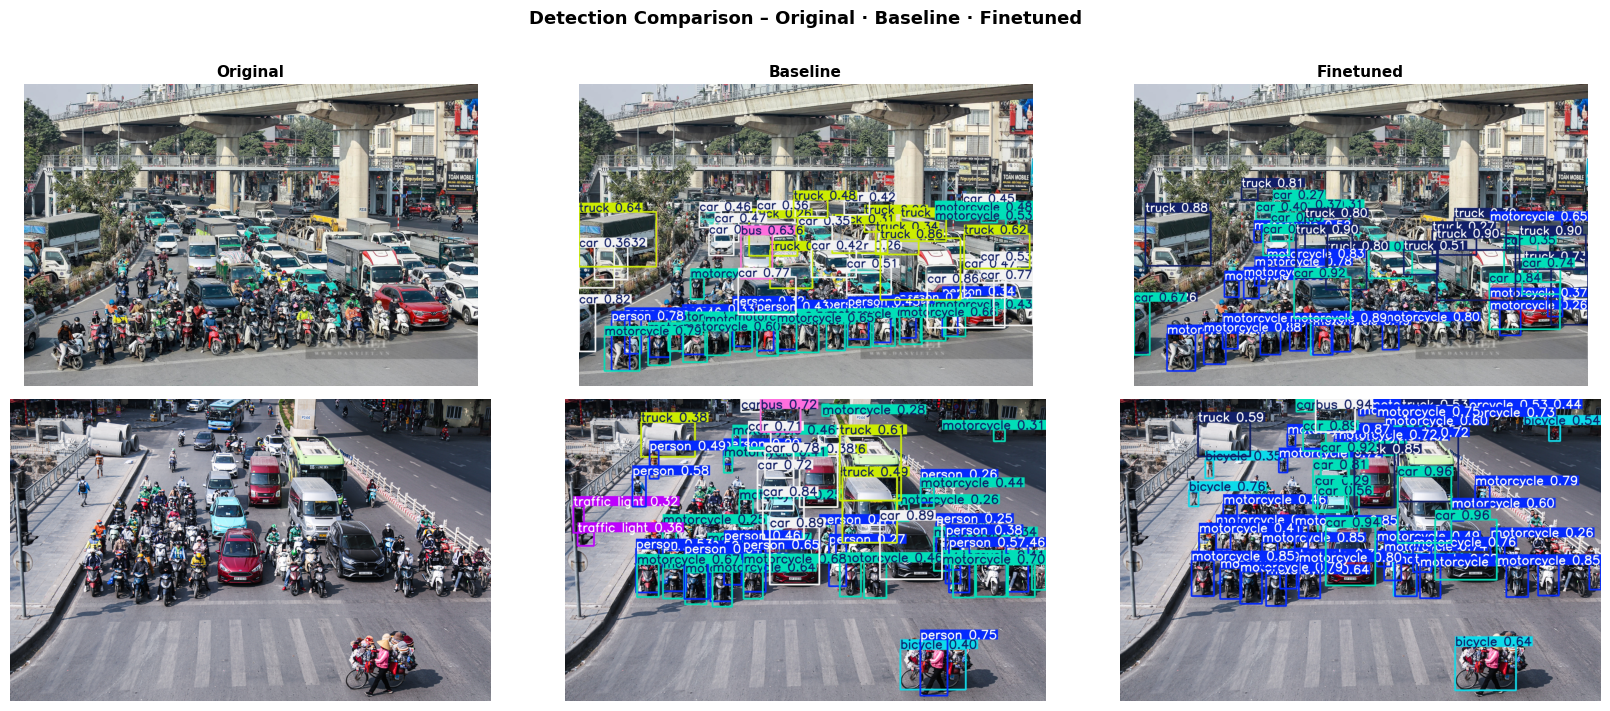

In [ ]:
compare_predictions(images_to_show = list(range(7, 10)))

In [ ]:
compare_predictions(images_to_show = list(range(10, 13)))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
compare_predictions(images_to_show = list(range(13, 16)))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
compare_predictions(images_to_show = list(range(16, 19)))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
compare_predictions(images_to_show = list(range(20, 23)))

Output hidden; open in https://colab.research.google.com to view.

,image,gt_total,weighted_score,density_ratio,priority
1,traffic_17.jpg,55,140.0,0.1437,0.4775
2,traffic_07.jpg,89,105.0,0.3710,0.4634
3,traffic_09.jpg,61,124.0,0.1298,0.4239
4,traffic_16.jpg,62,106.0,0.2136,0.4034
5,traffic_10.jpg,72,113.0,0.0917,0.3757
6,traffic_11.jpg,54,66.0,0.4385,0.3734
7,traffic_08.jpg,73,90.0,0.1466,0.3286
8,traffic_13.jpg,99,70.0,0.2465,0.3086
9,traffic_15.jpg,52,78.0,0.0711,0.2624
10,traffic_18.jpg,59,65.0,0.1159,0.2414


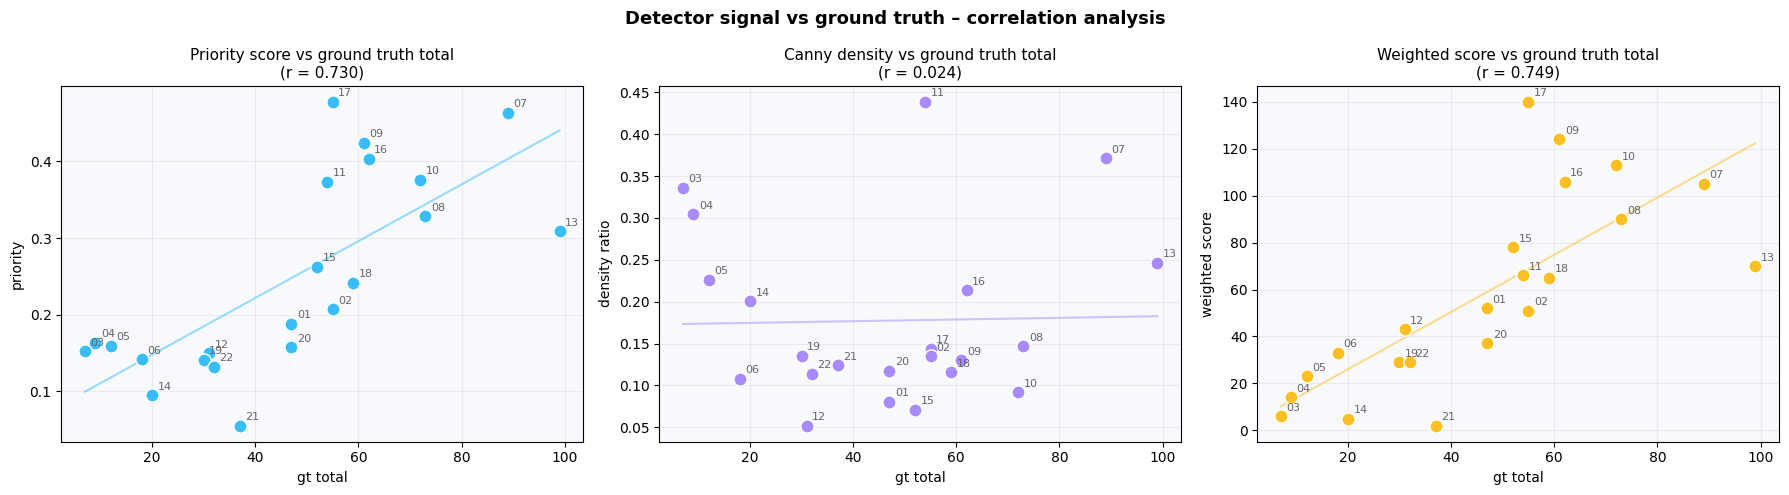

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

TEST_DIR = "/content/drive/MyDrive/Traffic State Optimization/Test"

ALPHA  = 0.6
BETA   = 0.4
MAX_WS = 200.0

GROUND_TRUTH = {
     1 : [42,  2,  3],   2 : [42, 13,  0],   3 : [ 7,  0,  0],
     4 : [ 8,  0,  1],   5 : [10,  2,  0],   6 : [14,  4,  0],
     7 : [55, 26,  8],   8 : [61,  8,  4],   9 : [39, 21,  1],
    10 : [42, 27,  3],  11 : [14, 36,  4],  12 : [21, 10,  0],
    13 : [74, 23,  2],  14 : [13,  6,  1],  15 : [32, 19,  1],
    16 : [32, 30,  0],  17 : [16, 33,  6],  18 : [53,  6,  0],
    19 : [27,  3,  0],  20 : [42,  5,  0],  21 : [36,  1,  0],
    22 : [25,  7,  0],
}

VEHICLE_CLASSES      = ["bicycle", "motorcycle", "car", "bus", "truck"]
LARGE_VEHICLE_CLASSES = ["car", "bus", "truck"]
VEHICLE_WEIGHTS      = {"bicycle": 1, "motorcycle": 1, "car": 2, "bus": 4, "truck": 5}

CANNY_LOW    = 50
CANNY_HIGH   = 150
BLUR_KERNEL  = (5, 5)
MORPH_KERNEL = np.ones((5, 5), np.uint8)
ZONE_TOP_RATIO = 0.25
ZONE_WEIGHTS = {"near": 0.5, "mid": 0.3, "far": 0.2}


# ---------------------------------------------------------------------------
# Canny hybrid density (same logic as detector.py)
# ---------------------------------------------------------------------------

def compute_edge_density(image, large_boxes) :
    img_h, img_w = image.shape[:2]

    gray         = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred      = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
    edges        = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)

    for (x1, y1, x2, y2) in large_boxes :
        cv2.rectangle(edges, (x1, y1), (x2, y2), 0, thickness = -1)

    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, MORPH_KERNEL)

    y_start = int(img_h * ZONE_TOP_RATIO)
    zone_h  = (img_h - y_start) // 3

    zones = {
        "far"  : (y_start,              y_start + zone_h),
        "mid"  : (y_start + zone_h,     y_start + 2 * zone_h),
        "near" : (y_start + 2 * zone_h, img_h),
    }

    densities = {}
    for zone_name, (y1, y2) in zones.items() :
        road_mask = np.full((y2 - y1, img_w), 255, dtype = np.uint8)
        for (bx1, by1, bx2, by2) in large_boxes :
            iy1 = max(y1, by1) - y1
            iy2 = min(y2, by2) - y1
            if iy1 < iy2 :
                cv2.rectangle(road_mask, (bx1, iy1), (bx2, iy2), 0, thickness = -1)
        road_area   = cv2.countNonZero(road_mask)
        edge_pixels = cv2.countNonZero(closed[y1:y2, :])
        densities[zone_name] = (edge_pixels / road_area) if road_area > 0 else 0.0

    return sum(ZONE_WEIGHTS[z] * densities[z] for z in ZONE_WEIGHTS)


# ---------------------------------------------------------------------------
# Extract metrics using finetuned model results already computed
# (reuses finetuned_results from the inference cell)
# ---------------------------------------------------------------------------

def extract_large_boxes(yolo_result) :
    boxes = []
    for box in yolo_result.boxes :
        label = yolo_result.names[int(box.cls[0])]
        if label in LARGE_VEHICLE_CLASSES :
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            boxes.append((x1, y1, x2, y2))
    return boxes


def extract_weighted_score(yolo_result) :
    score = 0
    for box in yolo_result.boxes :
        label = yolo_result.names[int(box.cls[0])]
        if label in VEHICLE_CLASSES :
            score += VEHICLE_WEIGHTS.get(label, 0)
    return score


def compute_priority(weighted_score, density) :
    normalized = min(weighted_score / MAX_WS, 1.0)
    return ALPHA * normalized + BETA * density


# ---------------------------------------------------------------------------
# Run on all 22 images using finetuned model
# ---------------------------------------------------------------------------

image_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(".jpg")])

rows = []

for r, fname in zip(finetuned_results, image_files) :

    n   = int(fname.replace("traffic_", "").replace(".jpg", ""))
    img = cv2.imread(os.path.join(TEST_DIR, fname))

    if img is None :
        continue

    large_boxes    = extract_large_boxes(r)
    weighted_score = extract_weighted_score(r)
    density        = compute_edge_density(img, large_boxes)
    priority       = compute_priority(weighted_score, density)

    gt       = GROUND_TRUTH.get(n, [0, 0, 0])
    gt_total = sum(gt)

    rows.append({
        "image"          : fname,
        "gt_total"       : gt_total,
        "weighted_score" : round(weighted_score, 1),
        "density_ratio"  : round(density, 4),
        "priority"       : round(priority, 4),
    })

df_rank = (pd.DataFrame(rows)
             .sort_values("priority", ascending = False)
             .reset_index(drop = True))
df_rank.index += 1

display(df_rank.style
    .background_gradient(subset = ["priority"],      cmap = "YlOrRd")
    .background_gradient(subset = ["density_ratio"], cmap = "Blues")
    .background_gradient(subset = ["gt_total"],      cmap = "Greens")
    .set_caption("Images ranked by computed priority score (finetuned model + Canny)")
    .format({"priority": "{:.4f}", "density_ratio": "{:.4f}", "weighted_score": "{:.1f}"})
)


# ---------------------------------------------------------------------------
# Scatter: does priority correlate with ground truth?
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

plots = [
    ("gt_total", "priority",       "#38BDF8", "Priority score vs ground truth total"),
    ("gt_total", "density_ratio",  "#A78BFA", "Canny density vs ground truth total"),
    ("gt_total", "weighted_score", "#FBBF24", "Weighted score vs ground truth total"),
]

for ax, (x_col, y_col, color, title) in zip(axes, plots) :
    ax.scatter(df_rank[x_col], df_rank[y_col],
               color = color, edgecolors = "white", s = 90, zorder = 3)
    for _, row in df_rank.iterrows() :
        ax.annotate(
            row["image"].replace("traffic_", "").replace(".jpg", ""),
            (row[x_col], row[y_col]),
            fontsize = 8, xytext = (4, 4), textcoords = "offset points", color = "#666"
        )
    # correlation line
    x = df_rank[x_col].values
    y = df_rank[y_col].values
    m, b   = np.polyfit(x, y, 1)
    corr   = np.corrcoef(x, y)[0, 1]
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color = color, alpha = 0.5, linewidth = 1.5)
    ax.set_xlabel(x_col.replace("_", " "))
    ax.set_ylabel(y_col.replace("_", " "))
    ax.set_title(f"{title}\n(r = {corr:.3f})", fontsize = 11)
    ax.grid(True, alpha = 0.2)
    ax.set_facecolor("#F8F9FC")

plt.suptitle("Detector signal vs ground truth – correlation analysis",
             fontsize = 13, fontweight = "bold")
plt.tight_layout()
plt.show()

In [ ]:
def visualize_pipeline_ranked(df_ranked, images_to_show = None, num_images = 5, img_height_inches = 4.0) :
    """
    Visualize pipeline stages sorted by priority rank.

    Parameters
    ----------
    df_ranked      : DataFrame from the ranking cell, sorted by priority descending
    images_to_show : list of rank positions (1-based) e.g. [1, 3, 5]
                     or list of image names e.g. ["traffic_07.jpg"]
                     or None → show top num_images
    num_images     : used when images_to_show is None
    """

    # resolve which rows to show
    if images_to_show is None :
        rows = df_ranked.iloc[:num_images]
    elif isinstance(images_to_show[0], int) and images_to_show[0] <= len(df_ranked) :
        # treat as rank positions (1-based)
        rows = df_ranked.iloc[[i - 1 for i in images_to_show]]
    else :
        # treat as image names
        rows = df_ranked[df_ranked["image"].isin(images_to_show)]

    sorted_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(".jpg")])
    n_rows       = len(rows)

    fig, axes = plt.subplots(n_rows, 3,
                              figsize = (img_height_inches * 3 * 1.5,
                                         img_height_inches * n_rows))
    if n_rows == 1 :
        axes = [axes]

    col_titles = ["Raw", "YOLO detections", "Canny edge map"]

    for row_idx, (_, row_data) in enumerate(rows.iterrows()) :

        fname  = row_data["image"]
        rank   = list(df_ranked["image"]).index(fname) + 1
        path   = os.path.join(TEST_DIR, fname)
        img    = cv2.imread(path)
        n      = int(fname.replace("traffic_", "").replace(".jpg", ""))

        if img is None :
            for ax in axes[row_idx] :
                ax.text(0.5, 0.5, "not found", ha = "center", va = "center",
                        transform = ax.transAxes, color = "red")
                ax.axis("off")
            continue

        # -- raw ------------------------------------------------------------
        axes[row_idx][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        # -- YOLO annotated -------------------------------------------------
        r_idx     = sorted_files.index(fname)
        yolo_r    = finetuned_results[r_idx]
        annotated = yolo_r.plot()
        axes[row_idx][1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

        # -- Canny with zones -----------------------------------------------
        large_boxes = extract_large_boxes(yolo_r)
        img_h, img_w = img.shape[:2]

        gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        edges   = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)
        for (x1, y1, x2, y2) in large_boxes :
            cv2.rectangle(edges, (x1, y1), (x2, y2), 0, thickness = -1)
        closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, MORPH_KERNEL)

        y_start = int(img_h * ZONE_TOP_RATIO)
        zone_h  = (img_h - y_start) // 3
        zone_map = {
            "far"  : (y_start,              y_start + zone_h),
            "mid"  : (y_start + zone_h,     y_start + 2 * zone_h),
            "near" : (y_start + 2 * zone_h, img_h),
        }

        canny_vis    = cv2.cvtColor(closed, cv2.COLOR_GRAY2BGR)
        zone_colors  = {"far": (0, 165, 255), "mid": (0, 220, 220), "near": (0, 230, 80)}

        densities = {}
        for zone_name, (y1, y2) in zone_map.items() :
            road_mask = np.full((y2 - y1, img_w), 255, dtype = np.uint8)
            for (bx1, by1, bx2, by2) in large_boxes :
                iy1 = max(y1, by1) - y1
                iy2 = min(y2, by2) - y1
                if iy1 < iy2 :
                    cv2.rectangle(road_mask, (bx1, iy1), (bx2, iy2), 0, thickness = -1)
            road_area   = cv2.countNonZero(road_mask)
            edge_pixels = cv2.countNonZero(closed[y1:y2, :])
            densities[zone_name] = (edge_pixels / road_area) if road_area > 0 else 0.0

            color = zone_colors[zone_name]
            cv2.line(canny_vis, (0, y1), (img_w, y1), color, 2)
            cv2.putText(canny_vis, f"{zone_name} {densities[zone_name]:.3f}",
                        (8, y1 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

        axes[row_idx][2].imshow(cv2.cvtColor(canny_vis, cv2.COLOR_BGR2RGB))

        # -- labels ---------------------------------------------------------
        for col_idx, ax in enumerate(axes[row_idx]) :
            ax.axis("off")

        # column titles on row 0 only, with extra top padding
        if row_idx == 0 :
            axes[0][1].set_title("YOLO detections", fontsize = 11, fontweight = "bold", pad = 8)
            axes[0][2].set_title("Canny edge map",  fontsize = 11, fontweight = "bold", pad = 8)

        # row title spanning full width – placed on middle panel
        axes[row_idx][1].set_title(
            f"rank #{rank}  ·  {fname}  ·  GT = {row_data['gt_total']}  ·  priority = {row_data['priority']:.4f}",
            fontsize = 10, fontweight = "bold", color = "#222",
            pad = 18 if row_idx == 0 else 8
        )

    plt.suptitle("Pipeline – Raw  ·  YOLO detections  ·  Canny edge map", fontsize = 13, fontweight = "bold")
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.1, top = 0.97)
    plt.show()


# ---------------------------------------------------------------------------
# Usage
# ---------------------------------------------------------------------------

# top 5 by priority
visualize_pipeline_ranked(df_rank, num_images = 22)

# specific ranks
# visualize_pipeline_ranked(df_rank, images_to_show = [1, 5, 10, 15, 22])

# specific image names
# visualize_pipeline_ranked(df_rank, images_to_show = ["traffic_07.jpg", "traffic_13.jpg", "traffic_03.jpg"])

NameError: name 'df_rank' is not defined

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

def save_pipeline_pdf(df_ranked,
                       output_path      = "/content/drive/MyDrive/Traffic State Optimization/pipeline_results.pdf",
                       rows_per_page    = 4,
                       img_height_inches = 3.5) :

    sorted_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith(".jpg")])
    all_rows     = list(df_ranked.iterrows())
    n_total      = len(all_rows)
    n_pages      = (n_total + rows_per_page - 1) // rows_per_page

    with PdfPages(output_path) as pdf :

        # -- Page 1: summary table ------------------------------------------
        fig_summary, ax_summary = plt.subplots(figsize = (16, 10))
        ax_summary.axis("off")

        # build table data
        WEIGHTS = [1, 2, 4.5]
        all_rows_data = []
        for _, row_data in df_ranked.iterrows() :
            n    = int(row_data["image"].replace("traffic_", "").replace(".jpg", ""))
            gt   = GROUND_TRUTH.get(n, [0, 0, 0])
            base = baseline_counts.get(n,  [0, 0, 0])
            fine = finetuned_counts.get(n, [0, 0, 0])
            gt_wt   = sum(gt[c]   * WEIGHTS[c] for c in range(3))
            base_wt = sum(base[c] * WEIGHTS[c] for c in range(3))
            fine_wt = sum(fine[c] * WEIGHTS[c] for c in range(3))
            acc_base = round(min(base_wt, gt_wt) / gt_wt * 100, 1) if gt_wt > 0 else 0.0
            acc_fine = round(min(fine_wt, gt_wt) / gt_wt * 100, 1) if gt_wt > 0 else 0.0
            all_rows_data.append([
                row_data["image"],
                row_data["gt_total"],
                f"{gt[0]} / {gt[1]} / {gt[2]}",
                f"{base[0]} / {base[1]} / {base[2]}",
                f"{fine[0]} / {fine[1]} / {fine[2]}",
                f"{acc_base}%",
                f"{acc_fine}%",
                f"{row_data['priority']:.4f}",
            ])

        col_labels = [
            "Image", "GT total",
            "GT (moto/car/heavy)",
            "Baseline (moto/car/heavy)",
            "Finetuned (moto/car/heavy)",
            "Acc baseline", "Acc finetuned",
            "Priority"
        ]

        tbl = ax_summary.table(
            cellText    = all_rows_data,
            colLabels   = col_labels,
            loc         = "center",
            cellLoc     = "center",
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.auto_set_column_width(col = list(range(len(col_labels))))

        # color header
        for col in range(len(col_labels)) :
            tbl[(0, col)].set_facecolor("#2C3E50")
            tbl[(0, col)].set_text_props(color = "white", fontweight = "bold")

        # color accuracy cells
        for row_i, row_data in enumerate(all_rows_data, start = 1) :
            for col_i in [5, 6] :
                val = float(row_data[col_i].replace("%", ""))
                if val >= 80 :
                    tbl[(row_i, col_i)].set_facecolor("#D5F5E3")
                elif val >= 60 :
                    tbl[(row_i, col_i)].set_facecolor("#FDEBD0")
                else :
                    tbl[(row_i, col_i)].set_facecolor("#FADBD8")

        # alternate row shading
        for row_i in range(1, len(all_rows_data) + 1) :
            if row_i % 2 == 0 :
                for col_i in range(len(col_labels)) :
                    if col_i not in [5, 6] :
                        tbl[(row_i, col_i)].set_facecolor("#F2F3F4")

        plt.suptitle("Detection Validation Summary — Baseline vs Finetuned",
                    fontsize = 14, fontweight = "bold", y = 0.98)
        plt.tight_layout()
        pdf.savefig(fig_summary, bbox_inches = "tight")
        plt.close(fig_summary)
        print("Page 1/summary saved")

        # -- remaining pages: image grids -----------------------------------
        # ... rest of your existing loop unchanged

        for page in range(n_pages) :

            page_rows = all_rows[page * rows_per_page : (page + 1) * rows_per_page]
            n_rows    = len(page_rows)

            fig, axes = plt.subplots(n_rows, 3,
                                      figsize = (img_height_inches * 3 * 1.5,
                                                 img_height_inches * n_rows))
            if n_rows == 1 :
                axes = [axes]

            if page == 0 :
                axes[0][1].set_title("YOLO detections", fontsize = 11, fontweight = "bold", pad = 8)
                axes[0][2].set_title("Canny edge map",  fontsize = 11, fontweight = "bold", pad = 8)

            for row_idx, (_, row_data) in enumerate(page_rows) :

                fname  = row_data["image"]
                rank   = list(df_ranked["image"]).index(fname) + 1
                path   = os.path.join(TEST_DIR, fname)
                img    = cv2.imread(path)

                if img is None :
                    for ax in axes[row_idx] :
                        ax.text(0.5, 0.5, "not found", ha = "center", va = "center",
                                transform = ax.transAxes, color = "red")
                        ax.axis("off")
                    continue

                # raw
                axes[row_idx][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

                # YOLO
                r_idx     = sorted_files.index(fname)
                yolo_r    = finetuned_results[r_idx]
                annotated = yolo_r.plot()
                axes[row_idx][1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

                # Canny
                large_boxes  = extract_large_boxes(yolo_r)
                img_h, img_w = img.shape[:2]
                gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
                edges   = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)
                for (x1, y1, x2, y2) in large_boxes :
                    cv2.rectangle(edges, (x1, y1), (x2, y2), 0, thickness = -1)
                closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, MORPH_KERNEL)

                y_start = int(img_h * ZONE_TOP_RATIO)
                zone_h  = (img_h - y_start) // 3
                zone_map = {
                    "far"  : (y_start,              y_start + zone_h),
                    "mid"  : (y_start + zone_h,     y_start + 2 * zone_h),
                    "near" : (y_start + 2 * zone_h, img_h),
                }
                canny_vis   = cv2.cvtColor(closed, cv2.COLOR_GRAY2BGR)
                zone_colors = {"far": (0, 165, 255), "mid": (0, 220, 220), "near": (0, 230, 80)}

                for zone_name, (y1, y2) in zone_map.items() :
                    road_mask = np.full((y2 - y1, img_w), 255, dtype = np.uint8)
                    for (bx1, by1, bx2, by2) in large_boxes :
                        iy1 = max(y1, by1) - y1
                        iy2 = min(y2, by2) - y1
                        if iy1 < iy2 :
                            cv2.rectangle(road_mask, (bx1, iy1), (bx2, iy2), 0, thickness = -1)
                    road_area   = cv2.countNonZero(road_mask)
                    edge_pixels = cv2.countNonZero(closed[y1:y2, :])
                    density     = (edge_pixels / road_area) if road_area > 0 else 0.0
                    color       = zone_colors[zone_name]
                    cv2.line(canny_vis, (0, y1), (img_w, y1), color, 2)
                    cv2.putText(canny_vis, f"{zone_name} {density:.3f}",
                                (8, y1 + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

                axes[row_idx][2].imshow(cv2.cvtColor(canny_vis, cv2.COLOR_BGR2RGB))

                for ax in axes[row_idx] :
                    ax.axis("off")

                gt = GROUND_TRUTH.get(int(fname.replace("traffic_", "").replace(".jpg", "")), [0, 0, 0])
                axes[row_idx][1].set_title(
                    f"rank #{rank}  ·  {fname}  ·  moto = {gt[0]}  car = {gt[1]}  heavy = {gt[2]}  ·  priority = {row_data['priority']:.4f}",
                    fontsize = 10, fontweight = "bold", color = "#222", pad = 8
                )

            plt.suptitle(
                f"Pipeline – Raw · YOLO · Canny   (page {page + 2}/{n_pages + 1})",
                fontsize = 12, fontweight = "bold"
            )
            plt.tight_layout()
            plt.subplots_adjust(hspace = 0.1, top = 0.95)
            pdf.savefig(fig, bbox_inches = "tight")
            plt.close(fig)
            print(f"Page {page + 1}/{n_pages} saved")

    print(f"\nPDF saved to: {output_path}")


save_pipeline_pdf(df_rank, rows_per_page = 4)

Page 1/summary saved
Page 1/6 saved
Page 2/6 saved
Page 3/6 saved
Page 4/6 saved
Page 5/6 saved
Page 6/6 saved

PDF saved to: /content/drive/MyDrive/Traffic State Optimization/pipeline_results.pdf
